# 1. Associative Memory and Fast Weights

> A fixed-size associative memory can store many key–value associations in the same weight matrix, but retrieval degrades through interference between overlapping keys — not because it runs out of discrete slots.

**Intended audience:** An ML-literate reader who knows linear algebra and basic attention, but has not thought carefully about fast-weight memory.

**Prerequisites:** Vector dot products, outer products, cosine similarity, and rough familiarity with attention.

## Learning objectives

1. Trace a key-value write into a fixed `d x d` weight matrix and read the association back.
2. Separate the desired signal from crosstalk caused by other stored keys.
3. Compare measured crosstalk with the approximate `sqrt(N / (d - 1))` scaling for this construction.
4. Explain why retrieval fails from key overlap rather than from exhausting a fixed number of slots.
5. Locate this same outer-product write inside Pathway's Dragon Hatchling architecture, and state where the toy diverges from it.

## 2. Live preset

This preset is computed when the notebook opens: `N=40`, `d=128`, independent random keys (`rho=0`), and no decay. The matrix is built by the importable implementation in `fastweights.py`.

The retrieved vector has already degraded measurably: its cosine with the true value is `0.87`, not `1.0`, even though top-1 ranking still succeeds for every stored key. Watch the crosstalk norm: it is the quantity that grows as other writes add cross-terms. Interference is continuous and starts immediately; retrieval failure is a late, visible symptom of damage that began at the second write. The rest of the notebook widens this gap and separates its signal from its crosstalk.

N=40, d=128, rho=0.0
Cosine similarity: 0.866
Crosstalk norm: 0.596
Top-1 retrieval accuracy: 100.0%


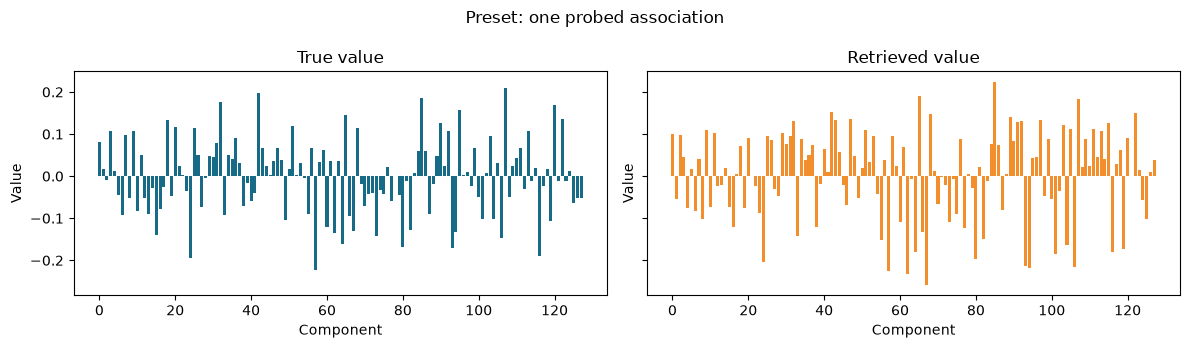

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from fastweights import FastWeightMemory, cosine, make_problem

def plot_truth_vs_read(true_value, retrieved, title):
    component_count = len(true_value)
    component_axis = np.arange(component_count)
    figure, axes = plt.subplots(1, 2, figsize=(12, 3.5), sharey=True)
    axes[0].bar(component_axis, true_value, color="#176b87")
    axes[0].set_title("True value")
    axes[1].bar(component_axis, retrieved, color="#f28e2b")
    axes[1].set_title("Retrieved value")
    for axis in axes:
        axis.set_xlabel("Component")
        axis.set_ylabel("Value")
    figure.suptitle(title)
    figure.tight_layout()
    plt.show()

preset_n, preset_d, preset_rho = 40, 128, 0.0
preset_keys, preset_values = make_problem(preset_n, preset_d, preset_rho, seed=2026)
preset_memory = FastWeightMemory.from_arrays(preset_keys, preset_values)
preset_index = 0
preset_retrieved = preset_memory.read(preset_keys[preset_index])
_, _, preset_crosstalk = preset_memory.decompose_read(preset_index)
print(f"N={preset_n}, d={preset_d}, rho={preset_rho:.1f}")
print(f"Cosine similarity: {cosine(preset_values[preset_index], preset_retrieved):.3f}")
print(f"Crosstalk norm: {np.linalg.norm(preset_crosstalk):.3f}")
print(f"Top-1 retrieval accuracy: {preset_memory.top1_accuracy():.1%}")
plot_truth_vs_read(preset_values[preset_index], preset_retrieved, "Preset: one probed association")

## 3. Guided walkthrough

The next three cells use incremental `write()` calls. The only thing changing is how many associations share the same matrix. Values remain independent of the keys' correlation so the experiment isolates key interference.

### One association

With one outer product, the query key meets itself with dot product one. There are no other terms to interfere, so the read is the stored value up to floating-point precision.

Cosine similarity: 1.000000


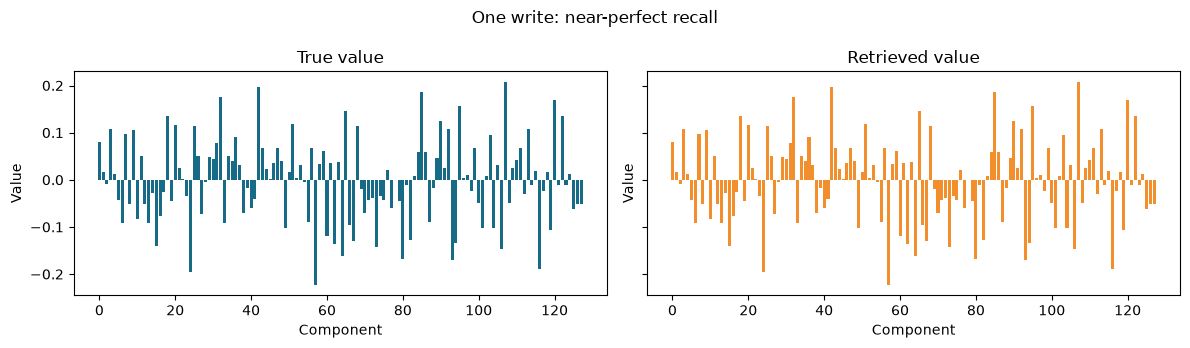

In [2]:
one_memory = FastWeightMemory(dimension=preset_d)
one_memory.write(preset_keys[0], preset_values[0])
one_retrieved = one_memory.read(preset_keys[0])
print(f"Cosine similarity: {cosine(preset_values[0], one_retrieved):.6f}")
plot_truth_vs_read(preset_values[0], one_retrieved, "One write: near-perfect recall")

### Five associations

Four additional outer products now contribute to a read of the first key. Random unit keys in finite dimensions do interfere: their pairwise dot products have mean zero but typical magnitude about `1/sqrt(d)`, so every additional write contributes a nonzero cross-term.

Cosine similarity: 0.994383


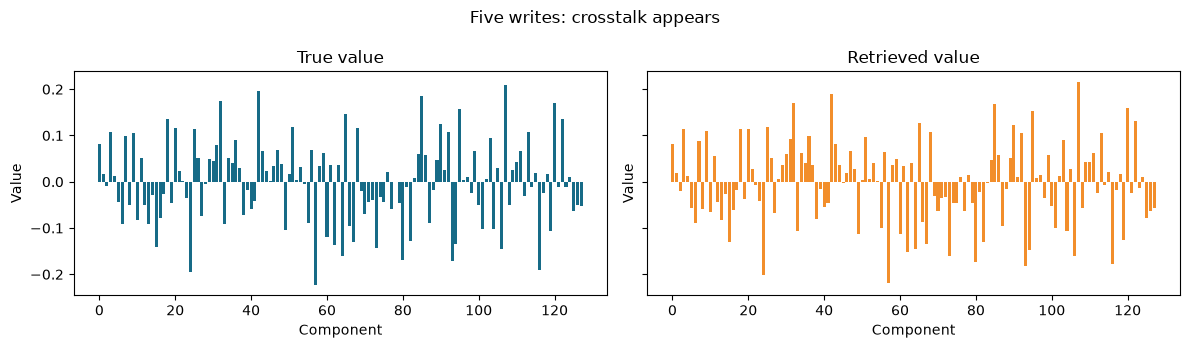

In [3]:
five_memory = FastWeightMemory(dimension=preset_d)
for key, value in zip(preset_keys[:5], preset_values[:5]):
    five_memory.write(key, value)
five_retrieved = five_memory.read(preset_keys[0])
print(f"Cosine similarity: {cosine(preset_values[0], five_retrieved):.6f}")
plot_truth_vs_read(preset_values[0], five_retrieved, "Five writes: crosstalk appears")

### Twenty associations

The matrix still has exactly `128 x 128` entries. The intuitive model of memory is a set of slots that fills up and then fails; this notebook tests that model. Here the read combines one self-term with nineteen cross-terms, so retrieval quality declines while the mechanism's size stays fixed. Later, hold `N` constant while raising key overlap. If the slot model were right, that manipulation should change nothing.

Matrix shape: (128, 128)
Cosine similarity: 0.946687


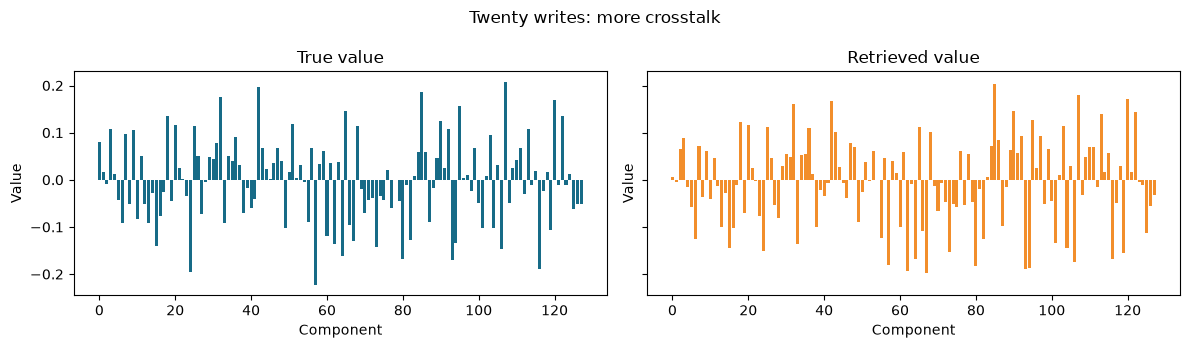

In [4]:
twenty_memory = FastWeightMemory(dimension=preset_d)
for key, value in zip(preset_keys[:20], preset_values[:20]):
    twenty_memory.write(key, value)
twenty_retrieved = twenty_memory.read(preset_keys[0])
print(f"Matrix shape: {twenty_memory.matrix.shape}")
print(f"Cosine similarity: {cosine(preset_values[0], twenty_retrieved):.6f}")
plot_truth_vs_read(preset_values[0], twenty_retrieved, "Twenty writes: more crosstalk")

## 4. The decomposition

For a stored key `k_j`, the implementation exposes the read as two vectors:

`v_hat = signal + crosstalk`

The signal is the target value multiplied by `k_j . k_j`. At decay `lambda=1`, it stays at unit magnitude because keys are normalized. With decay below one, it is additionally scaled by `decay ** (N - 1 - j)`, so older associations fade. Crosstalk is the sum of every other value multiplied by its overlap with `k_j`. The decomposition sums exactly to the read in either case.

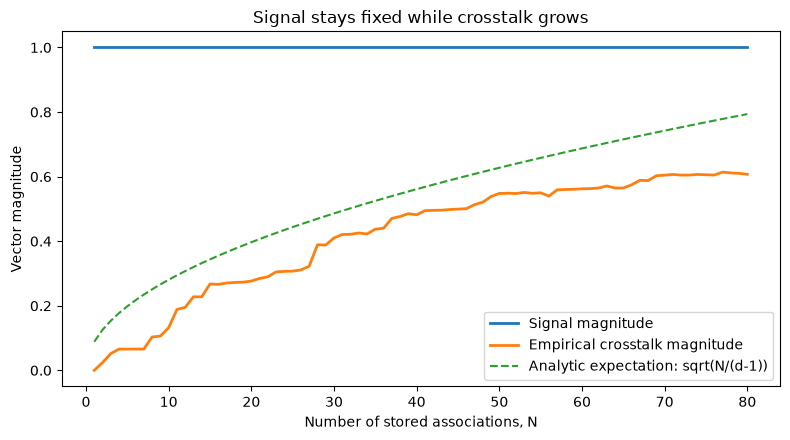

Caption: The signal remains at one; the empirical crosstalk rises with N and is compared with an analytic expectation, not a fit.


In [5]:
decomposition_n = 80
decomposition_d = 128
decomposition_keys, decomposition_values = make_problem(
    decomposition_n, decomposition_d, rho=0.0, seed=31415
)
signal_magnitudes = []
crosstalk_magnitudes = []
association_counts = np.arange(1, decomposition_n + 1)
for association_count in association_counts:
    memory = FastWeightMemory.from_arrays(
        decomposition_keys[:association_count],
        decomposition_values[:association_count],
    )
    _, signal, crosstalk = memory.decompose_read(0)
    signal_magnitudes.append(np.linalg.norm(signal))
    crosstalk_magnitudes.append(np.linalg.norm(crosstalk))

analytic_expectation = np.sqrt(association_counts / (decomposition_d - 1))
figure, axis = plt.subplots(figsize=(8, 4.5))
axis.plot(association_counts, signal_magnitudes, label="Signal magnitude", linewidth=2)
axis.plot(association_counts, crosstalk_magnitudes, label="Empirical crosstalk magnitude", linewidth=2)
axis.plot(association_counts, analytic_expectation, "--", label="Analytic expectation: sqrt(N/(d-1))")
axis.set_xlabel("Number of stored associations, N")
axis.set_ylabel("Vector magnitude")
axis.set_title("Signal stays fixed while crosstalk grows")
axis.legend()
figure.tight_layout()
plt.show()
print("Caption: The signal remains at one; the empirical crosstalk rises with N and is compared with an analytic expectation, not a fit.")

## 5. Interactive sandbox

Every control maps to one live variable in the memory experiment. The sandbox caps are `N <= 200` and `d <= 512` so each update remains interactive. The seed is fixed by default for reproducible comparisons. Values are generated with `make_problem()`: only key correlation changes with `rho`; values remain decorrelated.

1. Hold `d` and `rho` fixed and sweep `N`. Watch the crosstalk norm grow roughly as `sqrt(N / (d - 1))` while the signal term is unchanged.
2. Hold `N` and `rho` fixed and sweep `d`. The same number of associations becomes recoverable as dimension rises because random keys are closer to orthogonal in higher dimensions.
3. Hold `N` and `d` fixed and sweep `rho`. Retrieval degrades with no change in how many items are stored; this is the manipulation the slot model cannot explain.

Watch the crosstalk norm rather than accuracy: accuracy is a late indicator and can remain at 100% well after the retrieved vector has degraded.

In [6]:
import ipywidgets as widgets
from IPython.display import display

sandbox_n = widgets.IntSlider(description="N", min=1, max=200, value=40, step=1)
sandbox_d = widgets.IntSlider(description="d", min=16, max=512, value=128, step=8)
sandbox_rho = widgets.FloatSlider(description="rho", min=0.0, max=0.95, value=0.0, step=0.05)
sandbox_decay = widgets.FloatSlider(description="lambda", min=0.5, max=1.0, value=1.0, step=0.01)
sandbox_seed = widgets.IntSlider(description="seed", min=0, max=9999, value=2026, step=1)


def update_sandbox(n, d, rho, decay, seed):
    keys, values = make_problem(n=int(n), d=int(d), rho=float(rho), seed=int(seed))
    memory = FastWeightMemory.from_arrays(keys, values, decay=float(decay))
    probe_index = 0
    retrieved = memory.read(keys[probe_index])
    _, signal, crosstalk = memory.decompose_read(probe_index)

    print(f"N={int(n)}, d={int(d)}, rho={float(rho):.2f}, lambda={float(decay):.2f}, seed={int(seed)}")
    print(f"Cosine similarity: {cosine(values[probe_index], retrieved):.3f}")
    print(f"Top-1 retrieval accuracy: {memory.top1_accuracy():.1%}")
    print(f"Signal norm: {np.linalg.norm(signal):.3f}")
    print(f"Crosstalk norm: {np.linalg.norm(crosstalk):.3f}")

    figure, axes = plt.subplots(1, 2, figsize=(12, 3.8))
    component_axis = np.arange(int(d))
    axes[0].bar(component_axis - 0.2, values[probe_index], width=0.4, label="True value", color="#176b87")
    axes[0].bar(component_axis + 0.2, retrieved, width=0.4, label="Retrieved value", color="#f28e2b")
    axes[0].set_xlabel("Component")
    axes[0].set_ylabel("Value")
    axes[0].set_title("Truth beside estimate")
    axes[0].legend()
    axes[1].bar(["signal", "crosstalk"], [np.linalg.norm(signal), np.linalg.norm(crosstalk)], color=["#176b87", "#d1495b"])
    axes[1].set_xlabel("Read term")
    axes[1].set_ylabel("Vector magnitude")
    axes[1].set_title("Decomposition for probed key")
    figure.suptitle("Live computation: every control changes the memory experiment")
    figure.tight_layout()
    plt.show()
    print("Caption: Compare the true and retrieved components, then watch the crosstalk bar grow relative to the signal bar.")

sandbox_output = widgets.interactive_output(
    update_sandbox,
    {"n": sandbox_n, "d": sandbox_d, "rho": sandbox_rho, "decay": sandbox_decay, "seed": sandbox_seed},
)
display(widgets.VBox([sandbox_n, sandbox_d, sandbox_rho, sandbox_decay, sandbox_seed]), sandbox_output)

Output()

## 6. Misconception buster

Set `N` low and key overlap high. Then compare that memory with one holding ten times as many associations but nearly orthogonal random keys. The first failure comes from overlap, not from filling a slot budget.

In [7]:
comparison_dimension = 512
low_n_keys, low_n_values = make_problem(n=10, d=comparison_dimension, rho=0.9, seed=2026)
high_n_keys, high_n_values = make_problem(n=100, d=comparison_dimension, rho=0.0, seed=2026)
low_n_memory = FastWeightMemory.from_arrays(low_n_keys, low_n_values)
high_n_memory = FastWeightMemory.from_arrays(high_n_keys, high_n_values)

for label, keys, values, memory in (
    ("Low N, high overlap", low_n_keys, low_n_values, low_n_memory),
    ("High N, random keys", high_n_keys, high_n_values, high_n_memory),
):
    retrieved = memory.read(keys[0])
    _, _, crosstalk = memory.decompose_read(0)
    print(
        f"{label}: N={len(keys)}, d={comparison_dimension}, "
        f"rho={'0.90' if len(keys) == 10 else '0.00'} | "
        f"cosine={cosine(values[0], retrieved):.3f}, "
        f"crosstalk norm={np.linalg.norm(crosstalk):.3f}, "
        f"top-1 accuracy={memory.top1_accuracy():.1%}"
    )

Low N, high overlap: N=10, d=512, rho=0.90 | cosine=0.336, crosstalk norm=2.790, top-1 accuracy=20.0%
High N, random keys: N=100, d=512, rho=0.00 | cosine=0.913, crosstalk norm=0.440, top-1 accuracy=100.0%


**Prompt:** In your own words, why can a memory holding only 10 items fail while one holding 100 succeeds? Explain what changed in the key overlaps, and why that changes the cross-terms in the read.

## 7. BDH module

**Disclaimer:** This is an independent educational toy implementation of a fast-weight associative memory. It is **not an official BDH model, not a reimplementation of BDH, and produces no BDH results**. All BDH claims in this notebook must be cited to published primary sources.

This section uses BDH to connect the mechanism to a model architecture. It does not claim that this toy reproduces BDH.

### Source-verification scaffold

<!-- TODO-VERIFY: Confirm the primary source's exact name, authors, date, and definition of BDH. State which Dragon Hatchling system this notebook means. -->

**System boundary:** This notebook means BDH, the Dragon Hatchling architecture. <!-- TODO-VERIFY: Check whether BDH-CQ has any direct role in the mechanism discussed here. If it does not, say plainly that BDH-CQ has no direct role in this toy. -->

**Why fast weights appear:** The relevant connection is that BDH treats attention as a synaptic memory updated by Hebbian writes as the model reads. <!-- TODO-VERIFY: Replace this sentence with the paper's exact formulation and cite the primary BDH source. Do not add an equation from memory. -->

**What changes during inference:** The changing object is recurrent or synaptic state, not trained parameters. <!-- TODO-VERIFY: Confirm the paper's terminology for this state transition and its distinction from trained parameters. -->

**Toy correspondence and divergence:** Both the toy and BDH use an associative state updated by outer-product-like writes and queried by a read. This toy is dense and linear. BDH uses sparse non-negative ReLU activations, and BDH-GPU is described as a ReLU-low-rank formulation with linear attention. <!-- TODO-VERIFY: Check the exact BDH and BDH-GPU formulations, terminology, and scope in the primary source before treating any of these as claims. -->

**Primary sources:** Dragon Hatchling paper. <!-- TODO-VERIFY: Insert the verified bibliographic citation and public primary-source link. -->

BDH-CQ technical report. <!-- TODO-VERIFY: Insert the verified bibliographic citation and public primary-source link; state its relationship to this module only after checking the report. -->

## 8. Limitations

- **Different activation regime:** This toy is dense and linear. BDH uses sparse, non-negative activations. The toy therefore isolates the outer-product mechanism, not BDH's full computation.
- **Synthetic keys:** Keys here are random or generated with a shared-component correlation. Real models learn keys, producing a richer interference pattern.
- **Restricted correlation model:** At `rho=0`, noise lies in the `(d - 1)`-dimensional subspace perpendicular to the shared direction, so the crosstalk approximation is `sqrt(N / (d - 1))`, not `sqrt(N / d)`. For `rho > 0`, the construction puts all overlap in one shared direction; its expected Gram matrix is rank-one-plus-identity, unlike real learned correlations.
- **Mechanism isolation:** There is no sequence model, training loop, or language task. This isolates one write/read mechanism and says nothing about end-to-end model quality.
- **Interactive caps:** `N <= 200` and `d <= 512`. These caps keep widget updates under one second and keep matrix and comparison plots tractable in a browser; they are not claims about a model's capacity.

## 9. References

The references below are placeholders. Verify each primary source before committing, then replace the citation and link beside the specific claim it supports.

- `[Verified claim about BDH's fast-weight mechanism]` → `[Dragon Hatchling paper: verify title, authors, year]` → `[Public primary-source link: verify]`
- `[Verified claim about BDH-CQ and its relevance here]` → `[BDH-CQ technical report: verify title, authors, year]` → `[Public primary-source link: verify]`
- `[Verified claim about Mamba]` → `[Mamba (Gu and Dao): verify primary paper, title, authors, year]` → `[Public primary-source link: verify]`
- `[Verified claim about Gated Linear Attention]` → `[Yang et al.: verify primary paper, title, authors, year]` → `[Public primary-source link: verify]`
- `[Verified claim about DeltaNet or delta-rule linear transformers]` → `[Yang et al.: verify primary paper, title, authors, year]` → `[Public primary-source link: verify]`
- `[Verified claim about Titans: Learning to Memorize at Test Time]` → `[Behrouz et al.: verify primary paper, title, authors, year]` → `[Public primary-source link: verify]`

At least three verified primary papers dated 2022–2026 must be cited beside the claims they support. See `references.md` for the same verification list in claim → citation → link format.